In [4]:
from pathlib import Path
import sys

import torch

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.predict import (
    load_resnet50_model,
    predict_image,
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


Load final model

In [5]:
checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "resnet50_layer4_finetuned_best.pth"
)

model = load_resnet50_model(
    checkpoint_path=checkpoint_path,
    device=device,
)

print("Model loaded successfully")

Model loaded successfully


Run the prediction

In [22]:
image_path = (
    PROJECT_ROOT
    / "demo"
    / "test_images"
    / "my_metal.jpg"
)

result = predict_image(
    image_path=image_path,
    model=model,
    device=device,
)

print(
    "Predicted class:",
    result["class"],
)

print(
    f"Confidence: "
    f"{result['confidence'] * 100:.2f}%"
)

Predicted class: metal
Confidence: 100.00%


Show the image + prediction

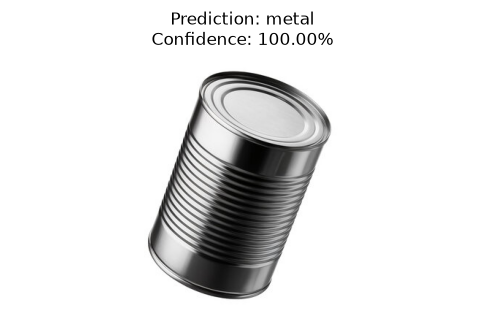

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction: {result['class']}\n"
    f"Confidence: {result['confidence'] * 100:.2f}%"
)

plt.show()

show Top-3 predictions

In [21]:
from src.evaluation.predict import (
    CLASS_NAMES,
    load_resnet50_model,
    predict_image,
)

In [24]:
import numpy as np

probabilities = result["probabilities"]

top3_indices = np.argsort(
    probabilities
)[-3:][::-1]

print("Top 3 predictions:")

for index in top3_indices:

    print(
        f"{CLASS_NAMES[index]:12s} "
        f"{probabilities[index] * 100:.2f}%"
    )

Top 3 predictions:
metal        100.00%
glass        0.00%
clothes      0.00%
